In [1]:
import sys
import nltk
import sklearn
import pandas as pd
import numpy as np

In [2]:
#version check
print("Python version:", sys.version)
print("NLTK version:", nltk.__version__)            
print("Scikit-learn version:", sklearn.__version__) 
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Python version: 3.13.2 (tags/v3.13.2:4f8bb39, Feb  4 2025, 15:23:48) [MSC v.1942 64 bit (AMD64)]
NLTK version: 3.9.2
Scikit-learn version: 1.8.0
Pandas version: 2.2.3
NumPy version: 2.2.4


In [3]:
import pandas as pd

# Load SMS spam dataset (the repo includes a pre-cleaned CSV with Label/Message columns)
sms = pd.read_csv('SMSSpamCollection.csv').drop(columns=['Unnamed: 0'], errors='ignore')
sms.head()

,Label,Message
0,ham,Go until jurong point crazy Available only in ...
1,ham,Ok lar Joking wif u oni
2,spam,Free entry in numbr a wkly comp to win FA Cup ...
3,ham,U dun say so early hor U c already then say
4,ham,Nah I don t think he goes to usf he lives arou...


In [4]:
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()
label = enc.fit_transform(sms['Label'])
print(label[:20])
print(sms['Label'][:20])

[0 0 1 0 0 1 0 0 1 1 0 1 1 0 0 1 0 0 0 1]
0      ham
1      ham
2     spam
3      ham
4      ham
5     spam
6      ham
7      ham
8     spam
9     spam
10     ham
11    spam
12    spam
13     ham
14     ham
15    spam
16     ham
17     ham
18     ham
19    spam
Name: Label, dtype: object


In [5]:
text  = sms['Message']
text[:10]

0    Go until jurong point crazy Available only in ...
1                              Ok lar Joking wif u oni
2    Free entry in numbr a wkly comp to win FA Cup ...
3          U dun say so early hor U c already then say
4    Nah I don t think he goes to usf he lives arou...
5    FreeMsg Hey there darling it s been numbr week...
6    Even my brother is not like to speak with me T...
7    As per your request Melle Melle Oru Minnaminun...
8    WINNER As a valued network customer you have b...
9    Had your mobile numbr months or more U R entit...
Name: Message, dtype: object

In [6]:
# Basic normalization: lowercase + remove punctuation/symbols
processed = text.fillna("").astype(str).str.lower()
processed = processed.str.replace(r"[^\w\s]", "", regex=True)

In [7]:
# Ensure required NLTK resources are available
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

# Remove stopwords
processed = processed.apply(lambda x: ' '.join(term for term in x.split() if term not in stop_words))

In [8]:
ps = nltk.PorterStemmer()
processed = processed.apply(lambda x: ' '.join(ps.stem(term) for term in str(x).split()))
processed

0       go jurong point crazi avail bugi n great world...
1                                   ok lar joke wif u oni
2       free entri numbr wkli comp win fa cup final tk...
3                     u dun say earli hor u c alreadi say
4                    nah think goe usf live around though
                              ...                        
5567    numbrnd time tri numbr contact u u moneysymbnu...
5568                              ü b go esplanad fr home
5569                                    piti mood suggest
5570    guy bitch act like interest buy someth els nex...
5571                                       rofl true name
Name: Message, Length: 5572, dtype: object

In [9]:
#FEATURE EXTRACTION
from nltk.tokenize import word_tokenize

all_words = []

for message in processed:
    words = word_tokenize(message)
    all_words.extend(words)

all_words = nltk.FreqDist(all_words)

print("Number of words: {}".format(len(all_words)))
print("Most common words: {}".format(all_words.most_common(20)))

Number of words: 6579
Most common words: [('numbr', 2648), ('u', 1207), ('call', 674), ('go', 456), ('get', 451), ('ur', 391), ('gt', 318), ('lt', 316), ('come', 304), ('moneysymbnumbr', 303), ('ok', 293), ('free', 284), ('day', 276), ('know', 275), ('love', 266), ('like', 261), ('got', 252), ('time', 252), ('good', 248), ('want', 247)]


In [10]:
words_features = [x[0] for x in all_words.most_common(1500)]

In [11]:
def find_features(message):
    words = word_tokenize(message)
    features = {}
    for w in words_features:
        features[w] = (w in words)
    return features

In [12]:
features = find_features(processed[0])
for key, value in features.items():
    if value == True:
        print(key)

go
got
n
great
wat
e
world
point
avail
crazi
bugi
la
cine


In [13]:
list(features.items())[:10]

[('numbr', False),
 ('u', False),
 ('call', False),
 ('go', True),
 ('get', False),
 ('ur', False),
 ('gt', False),
 ('lt', False),
 ('come', False),
 ('moneysymbnumbr', False)]

In [14]:
messages = list(zip(processed,label))

np.random.seed(1)
np.random.shuffle(messages)

In [15]:

feature_set = [(find_features(text), label) for (text, label) in messages]

In [16]:
from sklearn.model_selection import train_test_split
import pandas as pd
training, test = train_test_split(feature_set, test_size=0.25, random_state=1)

In [17]:

# Split the data
training, test = train_test_split(feature_set, test_size=0.25, random_state=1)

# Extract features (X) and labels (y) from training set
X_train = [f[0] for f in training]
y_train = [f[1] for f in training]  # Fixed: was 'test', should be 'training'

# Extract features (X) and labels (y) from test set
X_test = [f[0] for f in test]  # Added: was missing
y_test = [f[1] for f in test]  # Added: was missing

# Convert to pandas DataFrames and Series
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)  # Fixed: was using y_test
y_train = pd.Series(y_train)
y_test = pd.Series(y_test)

# Print shapes
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")



X_train shape: (4179, 1500), y_train shape: (4179,)
X_test shape: (1393, 1500), y_test shape: (1393,)


In [18]:
X_train.head()
print(X_train.head())

   numbr      u   call     go    get     ur     gt     lt   come  \
0   True  False  False  False  False   True  False  False  False   
1  False  False  False  False  False  False  False  False  False   
2  False  False  False  False  False  False  False  False  False   
3  False  False  False  False  False  False  False  False  False   
4   True  False   True  False  False  False  False  False  False   

   moneysymbnumbr  ...   bowl   site  salari  videophon  videochat   java  \
0            True  ...  False  False   False      False      False  False   
1           False  ...  False  False   False      False      False  False   
2           False  ...  False  False   False      False      False  False   
3           False  ...  False  False   False      False      False  False   
4           False  ...  False  False   False      False      False  False   

   dload  nolin  rentl    yun  
0  False  False  False  False  
1  False  False  False  False  
2  False  False  False  False  


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

In [20]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [21]:
y_pred = rf_model.predict(X_test)

report =classification_report(y_test,y_pred)
print("classification Report:")
print(report)

classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1199
           1       0.97      0.90      0.93       194

    accuracy                           0.98      1393
   macro avg       0.98      0.95      0.96      1393
weighted avg       0.98      0.98      0.98      1393



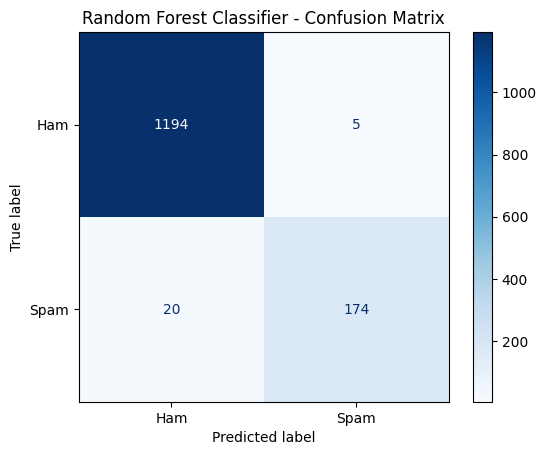

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=['Ham', 'Spam'])
disp.plot(cmap="Blues", values_format='d')
plt.title("Random Forest Classifier - Confusion Matrix")
plt.show()



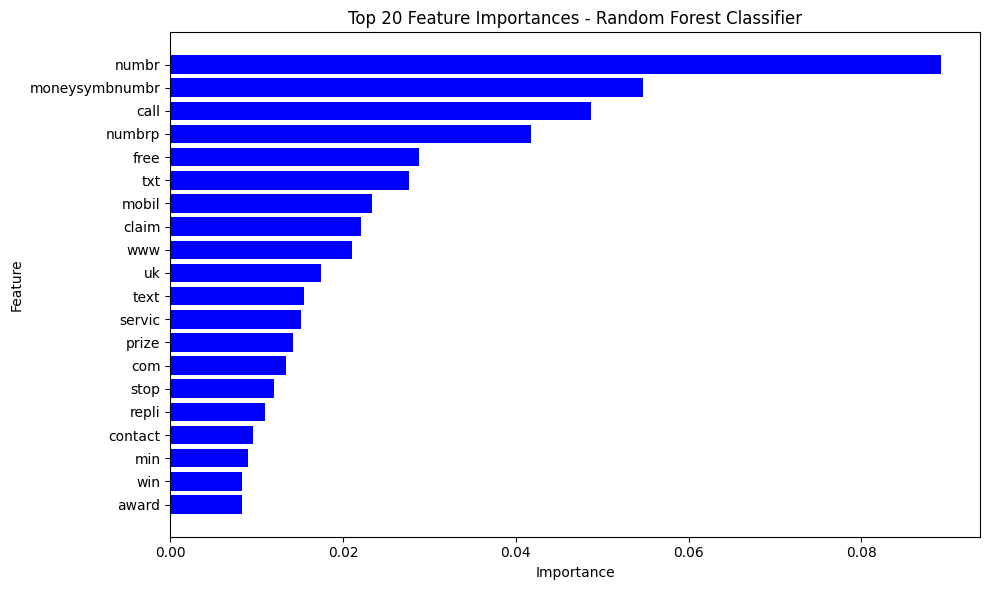

In [23]:
feature_names = X_train.columns

feature_importance = rf_model.feature_importances_

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'][:20], importance_df['Importance'][:20], color='blue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances - Random Forest Classifier')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [24]:
# RandomForest expects numeric features; convert booleans to 0/1
X_train_numeric = X_train.astype(int)
X_test_numeric = X_test.astype(int)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_numeric, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

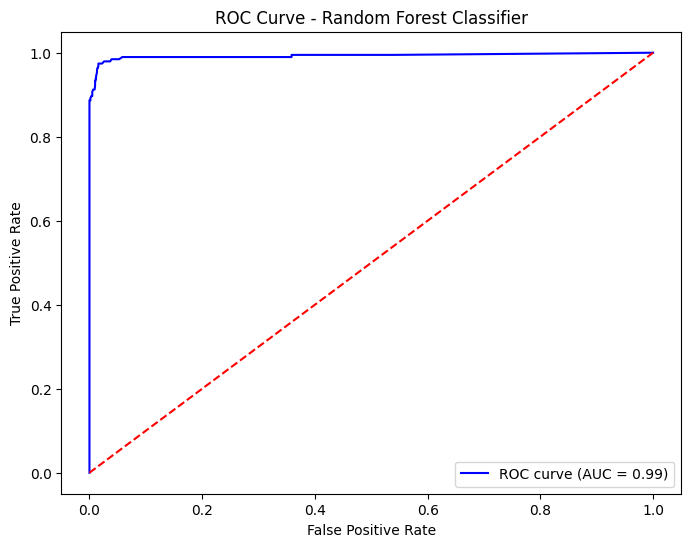

In [25]:
from sklearn.metrics import roc_auc_score, roc_curve

# ROC should be computed on held-out data (test set)
y_prob = rf_model.predict_proba(X_test_numeric)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest Classifier')
plt.legend(loc='lower right')
plt.show()

In [26]:
from nltk.classify.scikitlearn import SklearnClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [27]:
# Names must align 1:1 with the classifiers list below
names = [
    "KNN",
    "Decision Tree",
    "Random Forest",
    "Logistic Regression",
    "SGD Classifier",
    "MultinomialNB",
    "BernoulliNB",
    "SVC (linear)",
    "LinearSVC"
 ]

In [28]:
classifiers = [
    KNeighborsClassifier(),
    DecisionTreeClassifier(),
    RandomForestClassifier(n_estimators=200, random_state=42),
    LogisticRegression(max_iter=1000),
    SGDClassifier(random_state=42),
    MultinomialNB(),
    BernoulliNB(),
    SVC(kernel='linear'),
    LinearSVC()
 ]

In [29]:
models = zip(names, classifiers)
for name , model in models:
    nltk_model = SklearnClassifier(model)
    nltk_model.train(training)
    accuracy = nltk.classify.accuracy(nltk_model, test)
    print("{} model Accuracy: {}".format(name, accuracy))

KNN model Accuracy: 0.9475951184493898
Decision Tree model Accuracy: 0.95908111988514
Random Forest model Accuracy: 0.9820531227566404
Logistic Regression model Accuracy: 0.9834888729361091
SGD Classifier model Accuracy: 0.9806173725771715
MultinomialNB model Accuracy: 0.9856424982053122
BernoulliNB model Accuracy: 0.9834888729361091
SVC (linear) model Accuracy: 0.9820531227566404
LinearSVC model Accuracy: 0.9856424982053122


In [30]:
from sklearn.ensemble import VotingClassifier

#Since we are using the same models as before, we can reuse the 'classifiers' list

models = list(zip(names, classifiers))

nltk_ensemble = SklearnClassifier(VotingClassifier(estimators=models, voting='hard',n_jobs=-1))
nltk_ensemble.train(training)
accuracy = nltk.classify.accuracy(nltk_ensemble, test)
print("Voting Classifier model Accuracy: {}".format(accuracy))


Voting Classifier model Accuracy: 0.9849246231155779
